In [3]:
!pip install scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.0
[notice] To update, run: pip install --upgrade pip


In [4]:
import networkx as nx 

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import sklearn

from skimage.morphology import skeletonize
from skimage.util import img_as_ubyte


In [6]:
from skimage.measure import label
from scipy.ndimage import distance_transform_edt
from sklearn.decomposition import PCA
import networkx as nx
from collections import defaultdict

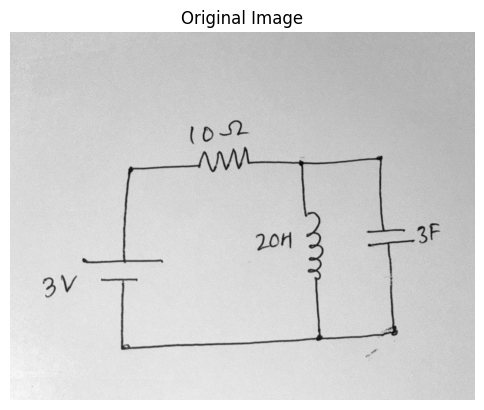

In [7]:
img_path = "/Users/mac/Downloads/LineDetect/ImageData/imgtotest.jpg"

img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

if img is None:
    raise FileNotFoundError(f"Image not found at {img_path}")

plt.figure(figsize=(6,6))
plt.imshow(img, cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.show()


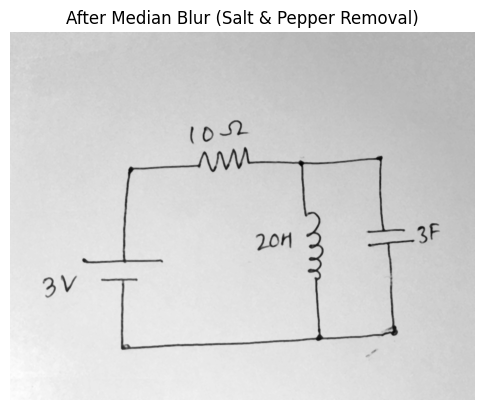

In [8]:
denoised = cv2.medianBlur(img, 5)

plt.figure(figsize=(6,6))
plt.imshow(denoised, cmap="gray")
plt.title("After Median Blur (Salt & Pepper Removal)")
plt.axis("off")
plt.show()


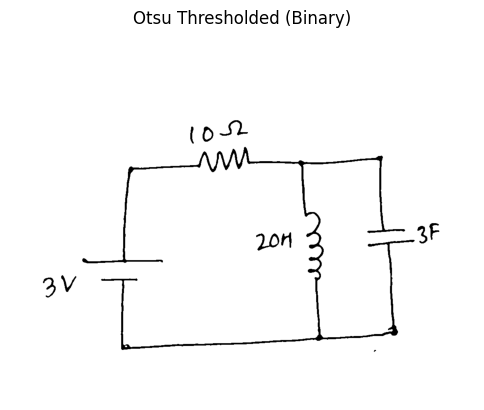

In [9]:
_, otsu_bin = cv2.threshold(denoised, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

plt.figure(figsize=(6,6))
plt.imshow(otsu_bin, cmap="gray")
plt.title("Otsu Thresholded (Binary)")
plt.axis("off")
plt.show()


In [10]:
print(otsu_bin)

[[255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 ...
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]]


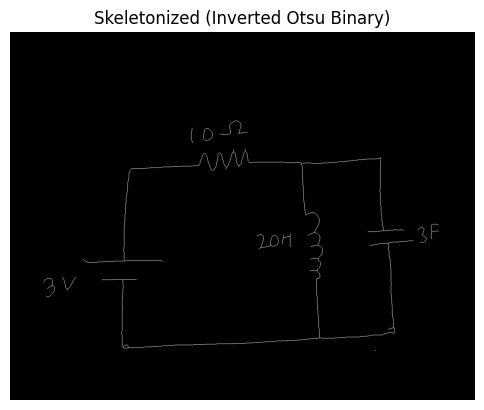

In [11]:
inverted = cv2.bitwise_not(otsu_bin)

# ensure binary is boolean
binary_bool = inverted > 0

# skeletonize
skeleton = skeletonize(binary_bool)

plt.figure(figsize=(6,6))
plt.imshow(skeleton, cmap="gray")
plt.title("Skeletonized (Inverted Otsu Binary)")
plt.axis("off")
plt.show()

In [12]:
label_path = "/Users/mac/Downloads/LineDetect/ImageData/imgtotest.txt"
img = otsu_bin
h, w = img.shape

with open(label_path, "r") as f:
    yolo_lines = [ln.strip() for ln in f.readlines() if ln.strip()]



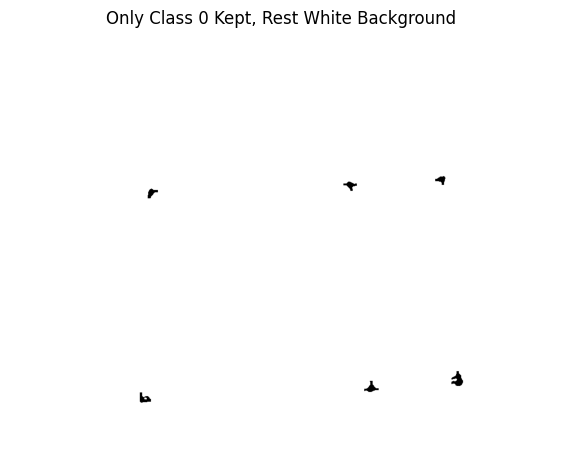

In [13]:
# --- Build mask from YOLO class 0 boxes ---
mask0 = np.zeros((h, w), dtype=np.uint8)

for ln in yolo_lines:
    parts = ln.split()
    if len(parts) < 5:
        continue
    if parts[0] != "1":
        continue

    # take only first 5 values (ignore confidence etc.)
    x, y, bw, bh = map(float, parts[1:5])

    x_center = int(x * w)
    y_center = int(y * h)
    box_w = int(bw * w)
    box_h = int(bh * h)

    x1 = max(0, x_center - box_w // 2)
    y1 = max(0, y_center - box_h // 2)
    x2 = min(w - 1, x_center + box_w // 2)
    y2 = min(h - 1, y_center + box_h // 2)

    cv2.rectangle(mask0, (x1, y1), (x2, y2), 255, thickness=-1)

# --- Keep only class 0 region, make rest white ---
result = np.full_like(img, 255)     # white background
result[mask0 == 255] = img[mask0 == 255]

plt.figure(figsize=(7,7))
plt.imshow(result, cmap="gray")
plt.title("Only Class 0 Kept, Rest White Background")
plt.axis("off")
plt.show()


Processing 14 lines from file...
Successfully removed 4 components. Kept Junctions.


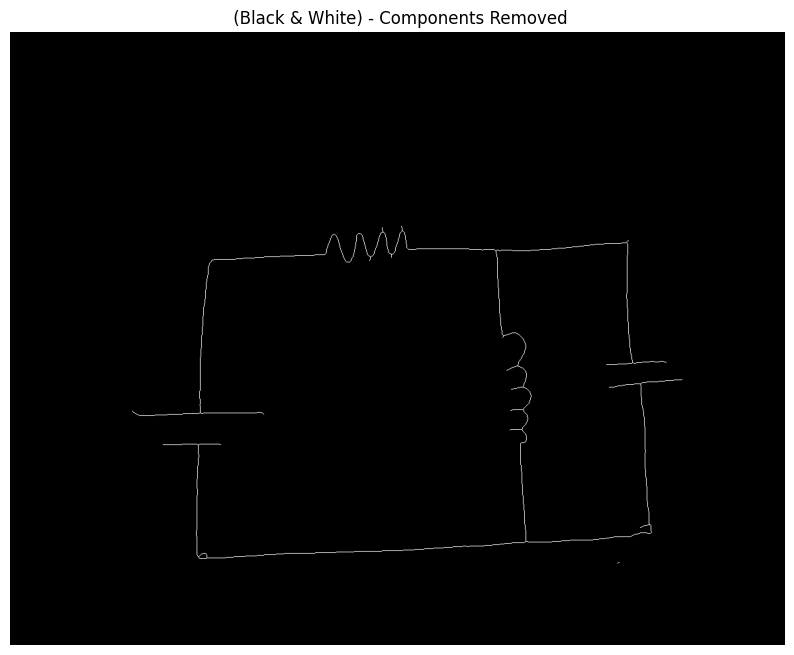

In [30]:
from matplotlib import image


def remove_components(image, label_path):
    # 1. FORCE GRAYSCALE (Black and White)
    # If the image has 3 channels (BGR/RGB), convert to 1 channel (Grayscale)
    cleaned_img = img
    
    # Get image dimensions
    img_h, img_w = cleaned_img.shape[:2]
    
    # 2. DEFINE ERASER FOR GRAYSCALE
    # For single channel images, Black is just 0 (scalar), not a tuple (0,0,0)
    ERASER_COLOR = 0
    
    try:
        with open(label_path, 'r') as f:
            lines = f.readlines()
            
        print(f"Processing {len(lines)} lines from file...")
        
        removed_count = 0
        
        for line in lines:
            parts = line.strip().split()
            if not parts: continue
            
            class_id = int(parts[0])
            
            # LOGIC: If it is NOT a junction (1), remove it
            if class_id == 0:
                # Parse normalized coordinates (0 to 1)
                x_center, y_center = float(parts[1]), float(parts[2])
                box_w, box_h = float(parts[3]), float(parts[4])
                
                # Convert to pixel coordinates
                x1 = int((x_center - box_w / 2) * img_w)
                y1 = int((y_center - box_h / 2) * img_h)
                x2 = int((x_center + box_w / 2) * img_w)
                y2 = int((y_center + box_h / 2) * img_h)
                
                # Clip coordinates
                x1, y1 = max(0, x1), max(0, y1)
                x2, y2 = min(img_w, x2), min(img_h, y2)
                
                # Draw filled black rectangle
                cv2.rectangle(cleaned_img, (x1, y1), (x2, y2), ERASER_COLOR, thickness=-1)
                
                removed_count += 1
                
        print(f"Successfully removed {removed_count} components. Kept Junctions.")
        return cleaned_img

    except FileNotFoundError:
        print(f"Error: The file {label_path} was not found.")
        return image

# --- EXECUTION ---

txt_path = '/Users/mac/Downloads/LineDetect/ImageData/imgtotest.txt'
img = skeleton.astype(np.uint8) * 255
# Assumes 'img' is already loaded
if 'img' in locals():
    # Run the removal (Returns a Grayscale image)
    masked = remove_components(img, txt_path)

    # 3. Show Result in Black and White
    plt.figure(figsize=(10, 10))
    
    # 'cmap="gray"' ensures it interprets the values as Black/White
    # 'vmin=0, vmax=255' ensures strictly black (0) to white (255) contrast
    plt.imshow(masked, cmap='gray', vmin=0, vmax=255)
    plt.title(" (Black & White) - Components Removed")
    plt.axis('off')
    plt.show()
    
    # Save the result as a proper grayscale PNG
    # cv2.imwrite("clean_skeleton_bw.png", final_skeleton)

else:
    print("Please load 'skeleton_img' first.")

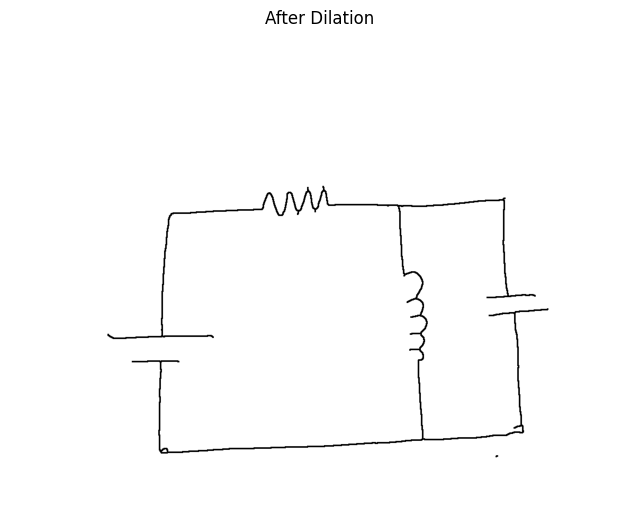

In [15]:
# invert so foreground becomes white for dilation
inv = cv2.bitwise_not(masked)
kernel = np.ones((3, 3), np.uint8)
dilated_inv = cv2.dilate(masked, kernel, iterations=1)

# invert back
dilated = cv2.bitwise_not(dilated_inv)

plt.figure(figsize=(8,8))
plt.imshow(dilated, cmap="gray", vmin=0, vmax=255)
plt.title("After Dilation")
plt.axis("off")
plt.show()


Foreground pixels: 11050
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


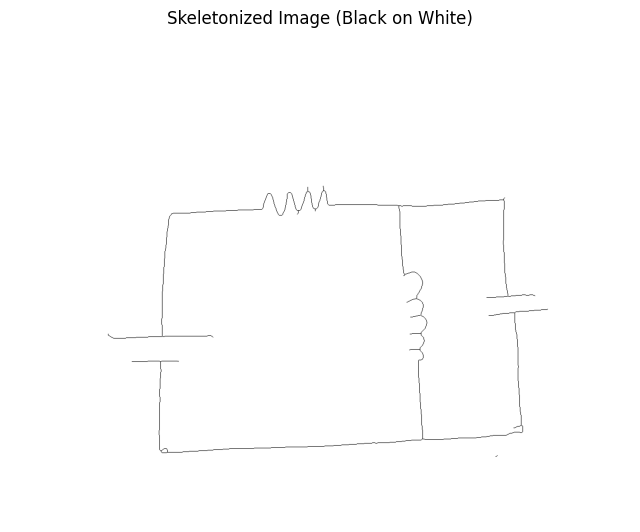

/Users/mac/Downloads/LineDetect/.venv/lib/python3.14/site-packages/skimage/_shared/utils.py:386: UserWarning: skeleton_black_on_white.png is a low contrast image
  return func(*args, **kwargs)


Skeleton image saved to skeleton_black_on_white.png


In [28]:
from skimage.io import imsave

# Foreground = black pixels
binary = (dilated < 128).astype(np.uint8)   # 1 where black line exists

print("Foreground pixels:", np.sum(binary))

skel = skeletonize(binary).astype(np.uint8)
skel_u8 = img_as_ubyte(skel)

# Convert to black skeleton on white background for display
skel_black_on_white = np.ones_like(dilated) * 255
skel_black_on_white[skel_u8 > 0] = 0
print(skel)

plt.figure(figsize=(8,8))
plt.imshow(skel_black_on_white, cmap="gray", vmin=0, vmax=255)
plt.title("Skeletonized Image (Black on White)")
plt.axis("off")
plt.show()


output_path = "skeleton_black_on_white.png"
imsave(output_path, skel_black_on_white.astype(np.uint8))

print(f"Skeleton image saved to {output_path}")

# Step 1: Parse All Components from Label File

We'll read the YOLO format label file and extract all bounding boxes with their class IDs.
Each line has format: `class_id x_center y_center width height [confidence]`

- Coordinates are normalized (0-1), so we multiply by image dimensions
- We store: class_id, center pixel coordinates, and bounding box corners

In [17]:
# Parse all components from the label file
# Each component will be stored as a dictionary with its properties

label_path = "/Users/mac/Downloads/LineDetect/ImageData/imgtotest.txt"

# Get image dimensions from the skeleton (skel is from previous cell)
img_h, img_w = skel.shape

def parse_yolo_labels(label_path, img_w, img_h):
    """
    Parse YOLO format labels and convert to pixel coordinates.
    
    YOLO format: class_id x_center y_center width height [confidence]
    - All coordinates are normalized (0 to 1)
    - x_center, y_center: center of bounding box
    - width, height: size of bounding box
    
    Returns: List of dictionaries with component info
    """
    components = []
    
    with open(label_path, 'r') as f:
        lines = f.readlines()
    
    for idx, line in enumerate(lines):
        parts = line.strip().split()
        if len(parts) < 5:
            continue
        
        # Extract values
        class_id = int(parts[0])
        x_norm, y_norm = float(parts[1]), float(parts[2])
        w_norm, h_norm = float(parts[3]), float(parts[4])
        confidence = float(parts[5]) if len(parts) > 5 else 1.0
        
        # Convert normalized coords to pixel coords
        x_center = int(x_norm * img_w)
        y_center = int(y_norm * img_h)
        box_w = int(w_norm * img_w)
        box_h = int(h_norm * img_h)
        
        # Calculate bounding box corners
        x1 = max(0, x_center - box_w // 2)
        y1 = max(0, y_center - box_h // 2)
        x2 = min(img_w - 1, x_center + box_w // 2)
        y2 = min(img_h - 1, y_center + box_h // 2)
        
        component = {
            'index': idx,
            'class_id': class_id,
            'center': (x_center, y_center),  # (x, y) pixel coords
            'bbox': (x1, y1, x2, y2),         # (x1, y1, x2, y2)
            'confidence': confidence
        }
        components.append(component)
    
    return components

# Parse all components
all_components = parse_yolo_labels(label_path, img_w, img_h)

# Separate Class 0 (blobs) from other components
class_0_components = [c for c in all_components if c['class_id'] == 0]
other_components = [c for c in all_components if c['class_id'] != 0]

print(f"Total components found: {len(all_components)}")
print(f"Class 0 (blobs/starting points): {len(class_0_components)}")
print(f"Other components (targets): {len(other_components)}")
print("\n--- Class 0 Components (Starting Points) ---")
for c in class_0_components:
    print(f"  Index {c['index']}: Center={c['center']}, BBox={c['bbox']}")
print("\n--- Other Components (Targets) ---")
for c in other_components:
    print(f"  Index {c['index']}: Class={c['class_id']}, Center={c['center']}")

Total components found: 14
Class 0 (blobs/starting points): 4
Other components (targets): 10

--- Class 0 Components (Starting Points) ---
  Index 10: Center=(1052, 504), BBox=(1021, 476, 1083, 532)
  Index 11: Center=(530, 249), BBox=(450, 216, 610, 282)
  Index 12: Center=(124, 638), BBox=(79, 606, 169, 670)
  Index 13: Center=(664, 525), BBox=(614, 499, 714, 551)

--- Other Components (Targets) ---
  Index 0: Class=1, Center=(779, 767)
  Index 1: Class=1, Center=(931, 316)
  Index 2: Class=1, Center=(733, 328)
  Index 3: Class=1, Center=(287, 792)
  Index 4: Class=1, Center=(304, 344)
  Index 5: Class=1, Center=(968, 750)
  Index 6: Class=12, Center=(281, 596)
  Index 7: Class=9, Center=(539, 318)
  Index 8: Class=15, Center=(764, 535)
  Index 9: Class=12, Center=(950, 515)


# Step 2: Find Intersection Points with Skeleton

For pathfinding endpoints, we need to find where each component connects to the skeleton:

**For Class 0 (blobs):** Find nearest skeleton pixel to the bounding box center
**For Other Classes:** Find skeleton pixels that intersect with the bounding box edges/boundary

If multiple intersection points exist, we'll select the one closest to the bounding box center.

In [18]:
def find_nearest_skeleton_pixel(center, skeleton):
    """Find nearest skeleton pixel to a given center point."""
    x, y = center
    
    # Get all skeleton pixel locations
    skel_y, skel_x = np.where(skeleton == 1)
    
    if len(skel_x) == 0:
        return None, float('inf')
    
    # Calculate distances
    distances = np.sqrt((skel_x - x)**2 + (skel_y - y)**2)
    min_idx = np.argmin(distances)
    
    return (skel_x[min_idx], skel_y[min_idx]), distances[min_idx]


def find_bbox_edge_intersections(bbox, skeleton):
    """
    Find skeleton pixels that intersect with bounding box edges.
    
    Parameters:
    - bbox: tuple (x1, y1, x2, y2) bounding box coordinates
    - skeleton: 2D numpy array where 1 = skeleton pixel
    
    Returns:
    - list of (x, y) coordinates where skeleton intersects bbox edges
    """
    x1, y1, x2, y2 = bbox
    intersections = []
    
    # Get all skeleton pixels
    skel_y, skel_x = np.where(skeleton == 1)
    
    # Check each skeleton pixel to see if it's on the bbox boundary
    for sx, sy in zip(skel_x, skel_y):
        # Check if pixel is on any of the 4 edges of the bounding box
        on_edge = False
        
        # Top edge: y = y1, x between x1 and x2
        if sy == y1 and x1 <= sx <= x2:
            on_edge = True
        # Bottom edge: y = y2, x between x1 and x2  
        elif sy == y2 and x1 <= sx <= x2:
            on_edge = True
        # Left edge: x = x1, y between y1 and y2
        elif sx == x1 and y1 <= sy <= y2:
            on_edge = True
        # Right edge: x = x2, y between y1 and y2
        elif sx == x2 and y1 <= sy <= y2:
            on_edge = True
        
        if on_edge:
            intersections.append((sx, sy))
    
    return intersections


def find_skeleton_endpoints(components, skeleton):
    """
    Find skeleton endpoint for each component.
    
    - Class 0: SKIP (not processed)
    - Class 1: Nearest skeleton pixel to center
    - Other classes: ALL skeleton pixels on bounding box edges
    """
    endpoints = []
    
    for comp in components:
        class_id = comp['class_id']
        center = comp['center']
        bbox = comp['bbox']
        
        # SKIP Class 0 completely
        if class_id == 0:
            continue
        
        result = {
            'component_index': comp['index'],
            'class_id': class_id,
            'center': center,
            'bbox': bbox,
            'intersection_points': [],
            'all_endpoints': [],  # For other classes, store all intersection points
            'selected_endpoint': None,
            'method': None,
            'distance_to_endpoint': None
        }
        
        if class_id == 1:
            # Class 1 (junctions): Find nearest skeleton pixel to center
            nearest_point, distance = find_nearest_skeleton_pixel(center, skeleton)
            if nearest_point is not None:
                result['intersection_points'] = [nearest_point]
                result['all_endpoints'] = [nearest_point]
                result['selected_endpoint'] = nearest_point
                result['method'] = 'nearest_to_center'
                result['distance_to_endpoint'] = distance
        else:
            # Other classes (9, 12, 15): Find ALL skeleton pixels on bbox edges
            edge_intersections = find_bbox_edge_intersections(bbox, skeleton)
            result['intersection_points'] = edge_intersections
            result['all_endpoints'] = edge_intersections.copy()  # Keep ALL intersection points
            result['method'] = 'bbox_edge_intersection_all'
            
            # No primary endpoint selection - keep all endpoints equally
            if edge_intersections:
                result['selected_endpoint'] = None  # No primary selection
                result['distance_to_endpoint'] = None
        
        endpoints.append(result)
    
    return endpoints


# Find skeleton endpoints for all components
print("Finding skeleton endpoints for all components...")
print("=" * 70)

component_endpoints = find_skeleton_endpoints(all_components, skel)

# Display results
for ep in component_endpoints:
    print(f"\nComponent {ep['component_index']} (Class {ep['class_id']}):")
    print(f"  Center: {ep['center']}")
    print(f"  BBox: {ep['bbox']}")
    print(f"  Method: {ep['method']}")
    print(f"  Intersection points found: {len(ep['intersection_points'])}")
    
    if ep['intersection_points']:
        if ep['class_id'] == 1:
            # Class 1: Show single nearest point
            print(f"  Nearest skeleton point: {ep['intersection_points'][0]}")
            print(f"  Distance: {ep['distance_to_endpoint']:.2f} pixels")
        else:
            # Other classes: Show all intersection points
            print(f"  ALL intersection points: {ep['intersection_points']}")
            print(f"  Total endpoints available: {len(ep['all_endpoints'])}")
            print(f"  No primary endpoint selected - all points equal")
    else:
        print(f"  ⚠️  No intersection points found!")

print(f"\n{'='*70}")

# Summary statistics
total_components = len(component_endpoints)
components_with_endpoints = sum(1 for ep in component_endpoints if ep['selected_endpoint'] is not None)
components_without_endpoints = total_components - components_with_endpoints

print(f"SUMMARY:")
print(f"  Total components processed: {total_components} (Class 0 skipped)")
print(f"  Components with endpoints: {components_with_endpoints}")
print(f"  Components without endpoints: {components_without_endpoints}")

# Count by class and method
class_counts = {}
method_counts = {}
total_intersection_points = 0

for ep in component_endpoints:
    class_id = ep['class_id']
    method = ep['method']
    
    class_counts[class_id] = class_counts.get(class_id, 0) + 1
    method_counts[method] = method_counts.get(method, 0) + 1
    total_intersection_points += len(ep.get('all_endpoints', ep['intersection_points']))

print(f"\nBY CLASS:")
for class_id in sorted(class_counts.keys()):
    count = class_counts[class_id]
    print(f"  Class {class_id}: {count} components")

print(f"\nBY METHOD:")
for method, count in method_counts.items():
    if method == 'nearest_to_center':
        print(f"  Nearest to center: {count} components (Class 1)")
    elif method == 'bbox_edge_intersection_all':
        print(f"  All bbox intersections: {count} components (Other classes)")

print(f"\nTOTAL INTERSECTION POINTS FOUND: {total_intersection_points}")

if components_without_endpoints > 0:
    print(f"\n⚠️  Components without endpoints:")
    for ep in component_endpoints:
        if ep['selected_endpoint'] is None:
            print(f"    Component {ep['component_index']} (Class {ep['class_id']})")

print(f"{'='*70}")

Finding skeleton endpoints for all components...

Component 0 (Class 1):
  Center: (779, 767)
  BBox: (764, 753, 794, 781)
  Method: nearest_to_center
  Intersection points found: 1
  Nearest skeleton point: (np.int64(779), np.int64(767))
  Distance: 0.00 pixels

Component 1 (Class 1):
  Center: (931, 316)
  BBox: (917, 303, 945, 329)
  Method: nearest_to_center
  Intersection points found: 1
  Nearest skeleton point: (np.int64(932), np.int64(316))
  Distance: 1.00 pixels

Component 2 (Class 1):
  Center: (733, 328)
  BBox: (719, 314, 747, 342)
  Method: nearest_to_center
  Intersection points found: 1
  Nearest skeleton point: (np.int64(733), np.int64(329))
  Distance: 1.00 pixels

Component 3 (Class 1):
  Center: (287, 792)
  BBox: (271, 778, 303, 806)
  Method: nearest_to_center
  Intersection points found: 1
  Nearest skeleton point: (np.int64(286), np.int64(791))
  Distance: 1.41 pixels

Component 4 (Class 1):
  Center: (304, 344)
  BBox: (290, 330, 318, 358)
  Method: nearest_to_

# Step 3: Visualize Intersection Points

Create an overlay visualization showing:
- **Gray**: Skeleton pixels
- **Colored rectangles**: Bounding boxes for each class
- **Colored circles**: Selected endpoints
- **Small dots**: All intersection points found
- **Component numbers**: For easy identification

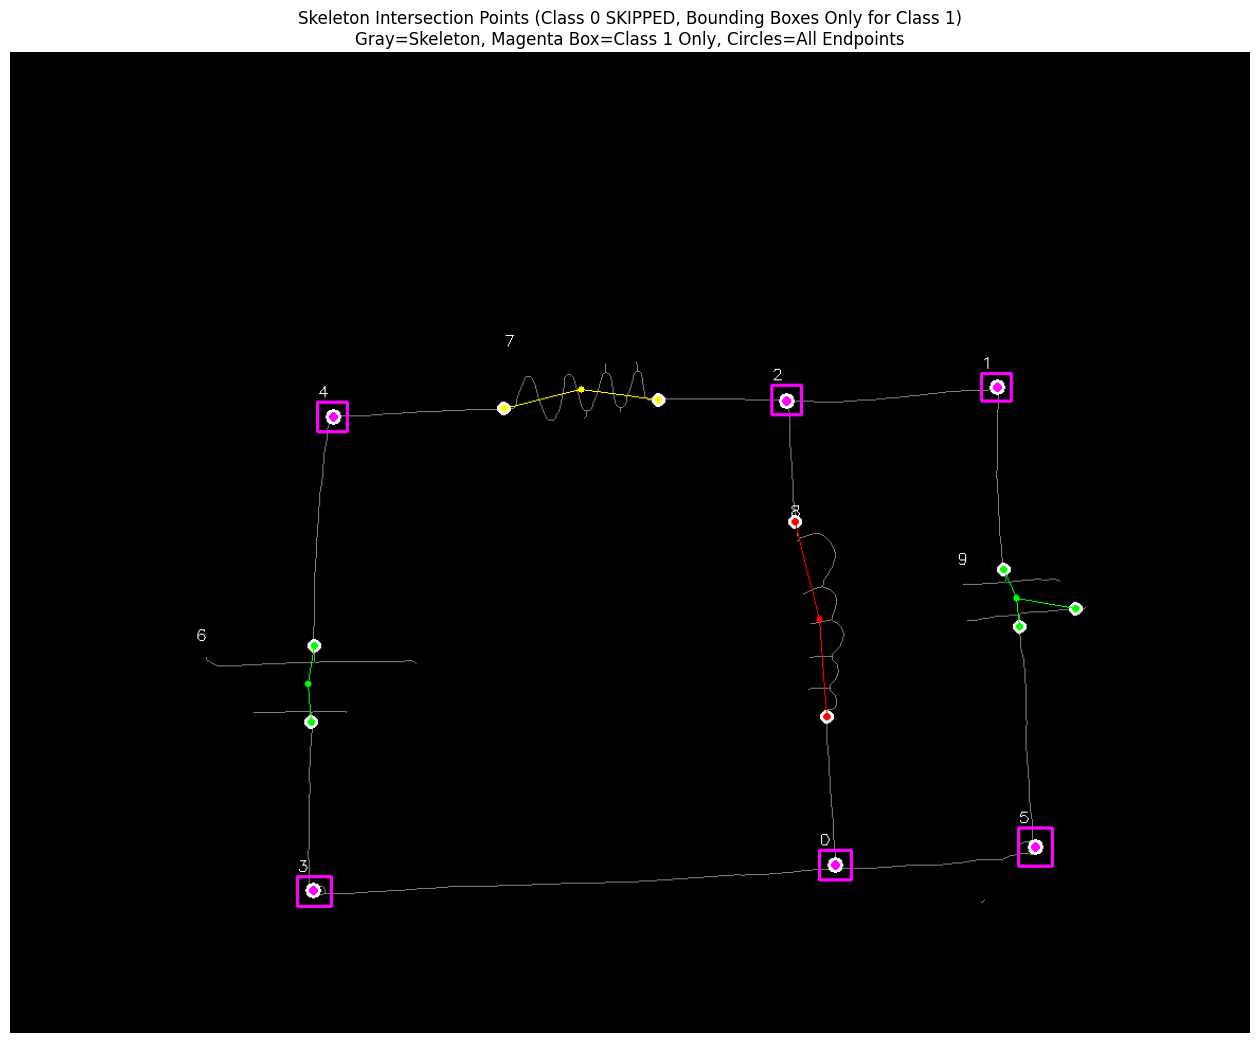


VISUALIZATION LEGEND:
🔲 Gray pixels: Skeleton
📦 Colored rectangles: Bounding boxes
📍 Tiny filled circles: Component centers
📝 White numbers: Component indices
━ Colored lines: Center to endpoint connections

FOR CLASS 1 (Junctions):
⭕ Large colored circle: Nearest skeleton point

FOR OTHER CLASSES (9, 12, 15):
⭕ Medium colored circles: All intersection points (equal treatment)
━ Lines: To all intersection points
📦 Bounding boxes: HIDDEN (only Class 1 shows bounding box)

CLASS COLORS:
------------------------------
Class 1: Magenta (6 components)
Class 9: Yellow (1 components)
Class 12: Green (2 components)
Class 15: Red (1 components)

PROCESSING METHODS:
------------------------------
📍 Nearest to center: 6 components (Class 1)
📦 All BBox edge intersections: 4 components (Other classes)

⚠️  Class 0 components: SKIPPED (not processed)


In [19]:
# Create comprehensive visualization
plt.figure(figsize=(16, 16))

# Start with skeleton as base
vis_img = np.zeros((skel.shape[0], skel.shape[1], 3), dtype=np.uint8)
vis_img[skel == 1] = [128, 128, 128]  # Gray skeleton

# Define colors for each class
class_colors = {
    0: (0, 255, 255),    # Cyan for Class 0 (blobs)
    1: (255, 0, 255),    # Magenta for Class 1 (junctions) 
    9: (255, 255, 0),    # Yellow for Class 9
    12: (0, 255, 0),     # Green for Class 12
    15: (255, 0, 0),     # Red for Class 15
}

# Draw components
for ep in component_endpoints:
    class_id = ep['class_id']
    center = ep['center']
    bbox = ep['bbox']
    intersection_points = ep['intersection_points']
    all_endpoints = ep.get('all_endpoints', intersection_points)  # Get all endpoints
    selected_endpoint = ep['selected_endpoint']
    
    # Get color for this class
    color = class_colors.get(class_id, (255, 255, 255))  # Default white
    
    # Draw bounding box rectangle only for Class 1
    if class_id == 1:
        x1, y1, x2, y2 = bbox
        cv2.rectangle(vis_img, (x1, y1), (x2, y2), color, 2)
    
    # Draw center point as small filled circle
    cv2.circle(vis_img, center, 3, color, -1)
    
    if class_id == 1:
        # Class 1: Draw single nearest point
        if selected_endpoint is not None:
            cv2.circle(vis_img, selected_endpoint, 6, color, -1)  # Filled
            cv2.circle(vis_img, selected_endpoint, 6, (255, 255, 255), 2)  # White border
            cv2.line(vis_img, center, selected_endpoint, color, 1)
    else:
        # Other classes: Draw ALL intersection points equally
        for point in all_endpoints:
            # All endpoints equal - same size circles
            cv2.circle(vis_img, point, 5, color, -1)  # Filled
            cv2.circle(vis_img, point, 5, (255, 255, 255), 2)  # White border
            cv2.line(vis_img, center, point, color, 1)  # Line to all endpoints
    
    # Add component index label
    text_pos = (bbox[0], bbox[1] - 5) if bbox[1] > 15 else (bbox[0], bbox[3] + 15)
    cv2.putText(vis_img, str(ep['component_index']), text_pos, 
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

plt.imshow(vis_img)
plt.title("Skeleton Intersection Points (Class 0 SKIPPED, Bounding Boxes Only for Class 1)\n" +
          "Gray=Skeleton, Magenta Box=Class 1 Only, Circles=All Endpoints")
plt.axis('off')
plt.show()

# Create detailed legend
print("\nVISUALIZATION LEGEND:")
print("=" * 50)
print("🔲 Gray pixels: Skeleton")
print("📦 Colored rectangles: Bounding boxes")
print("📍 Tiny filled circles: Component centers")
print("📝 White numbers: Component indices")
print("━ Colored lines: Center to endpoint connections")
print()
print("FOR CLASS 1 (Junctions):")
print("⭕ Large colored circle: Nearest skeleton point")
print()
print("FOR OTHER CLASSES (9, 12, 15):")
print("⭕ Medium colored circles: All intersection points (equal treatment)")
print("━ Lines: To all intersection points")
print("📦 Bounding boxes: HIDDEN (only Class 1 shows bounding box)")

print("\nCLASS COLORS:")
print("-" * 30)
color_names = {1: "Magenta", 9: "Yellow", 12: "Green", 15: "Red"}
for class_id in sorted(set(ep['class_id'] for ep in component_endpoints)):
    color_name = color_names.get(class_id, "White")
    count = sum(1 for ep in component_endpoints if ep['class_id'] == class_id)
    print(f"Class {class_id}: {color_name} ({count} components)")

print("\nPROCESSING METHODS:")
print("-" * 30)
method_counts = {}
for ep in component_endpoints:
    method = ep['method']
    if method:
        method_counts[method] = method_counts.get(method, 0) + 1

for method, count in method_counts.items():
    if method == 'nearest_to_center':
        print(f"📍 Nearest to center: {count} components (Class 1)")
    elif method == 'bbox_edge_intersection_all':
        print(f"📦 All BBox edge intersections: {count} components (Other classes)")

print(f"\n⚠️  Class 0 components: SKIPPED (not processed)")
print("=" * 50)

# Step 4: Collect All Endpoints into Array

Now we'll collect all the calculated endpoints into a single array for easy access and processing.

In [20]:
# Extract all calculated endpoints into arrays for easy access
print("Extracting all calculated endpoints...")
print("=" * 50)

# Arrays to store different types of endpoints
class_1_coordinates = []        # Junction points (Class 1)
all_other_intersection_points = []  # All intersection points from other classes
pathfinding_endpoints = []      # Complete list for pathfinding algorithm

# Extract endpoints from component_endpoints
for ep in component_endpoints:
    class_id = ep['class_id']
    component_index = ep['component_index']
    
    if class_id == 1:
        # Class 1: Single nearest skeleton point
        if ep['selected_endpoint'] is not None:
            point = ep['selected_endpoint']
            class_1_coordinates.append(point)
            pathfinding_endpoints.append({
                'component_index': component_index,
                'class_id': class_id,
                'endpoint': point,
                'type': 'junction'
            })
            print(f"Class 1 - Component {component_index}: {point}")
    else:
        # Other classes: All intersection points
        all_endpoints = ep.get('all_endpoints', ep['intersection_points'])
        for point in all_endpoints:
            all_other_intersection_points.append(point)
            pathfinding_endpoints.append({
                'component_index': component_index,
                'class_id': class_id,
                'endpoint': point,
                'type': 'edge_intersection'
            })
        if all_endpoints:
            print(f"Class {class_id} - Component {component_index}: {len(all_endpoints)} endpoints -> {all_endpoints}")

print("\n" + "=" * 50)
print("ENDPOINT SUMMARY:")
print(f"Class 1 (junctions): {len(class_1_coordinates)} endpoints")
print(f"Other classes: {len(all_other_intersection_points)} endpoints")
print(f"Total pathfinding endpoints: {len(pathfinding_endpoints)} endpoints")

print(f"\nClass 1 coordinates: {class_1_coordinates}")
print(f"All other intersection points: {all_other_intersection_points}")

# Verify we have endpoints
if len(pathfinding_endpoints) == 0:
    print("⚠️  WARNING: No endpoints found!")
else:
    print(f"\n✅ Ready for pathfinding with {len(pathfinding_endpoints)} total endpoints")
print("=" * 50)

Extracting all calculated endpoints...
Class 1 - Component 0: (np.int64(779), np.int64(767))
Class 1 - Component 1: (np.int64(932), np.int64(316))
Class 1 - Component 2: (np.int64(733), np.int64(329))
Class 1 - Component 3: (np.int64(286), np.int64(791))
Class 1 - Component 4: (np.int64(305), np.int64(344))
Class 1 - Component 5: (np.int64(968), np.int64(750))
Class 12 - Component 6: 2 endpoints -> [(np.int64(287), np.int64(560)), (np.int64(284), np.int64(632))]
Class 9 - Component 7: 2 endpoints -> [(np.int64(612), np.int64(328)), (np.int64(466), np.int64(336))]
Class 15 - Component 8: 2 endpoints -> [(np.int64(741), np.int64(443)), (np.int64(771), np.int64(627))]
Class 12 - Component 9: 3 endpoints -> [(np.int64(938), np.int64(488)), (np.int64(1006), np.int64(525)), (np.int64(953), np.int64(542))]

ENDPOINT SUMMARY:
Class 1 (junctions): 6 endpoints
Other classes: 9 endpoints
Total pathfinding endpoints: 15 endpoints

Class 1 coordinates: [(np.int64(779), np.int64(767)), (np.int64(932

In [21]:
# Extract blob coordinates (Class 0) from all_components
print("Extracting Class 0 blob coordinates...")
print("=" * 50)

# Filter Class 0 components (blobs) from all_components
blob_components = [c for c in all_components if c['class_id'] == 0]

# Extract blob information
blob_coordinates = []
blob_centers = []
blob_bboxes = []

for blob in blob_components:
    index = blob['index']
    center = blob['center']  # (x, y)
    bbox = blob['bbox']      # (x1, y1, x2, y2)
    confidence = blob['confidence']
    
    blob_coordinates.append({
        'index': index,
        'center': center,
        'bbox': bbox,
        'confidence': confidence
    })
    
    blob_centers.append(center)
    blob_bboxes.append(bbox)

# Create simple coordinate arrays
blob_coordinate_array = [blob['center'] for blob in blob_coordinates]

# Display results
print(f"Number of blobs found: {len(blob_coordinates)}")
print(f"Number of blob coordinates: {len(blob_coordinate_array)}")
print()
print("BLOB DETAILS:")
print("-" * 30)

for i, blob in enumerate(blob_coordinates):
    print(f"Blob {i+1} (Component {blob['index']}):")
    print(f"  Center: {blob['center']}")
    print(f"  Bounding Box: {blob['bbox']}")
    print(f"  Confidence: {blob['confidence']:.3f}")
    print()

print("BLOB COORDINATE ARRAY:")
print("-" * 30)
print(f"blob_coordinate_array = {blob_coordinate_array}")
print()
print(f"Total blob count: {len(blob_coordinate_array)}")
print("=" * 50)

Extracting Class 0 blob coordinates...
Number of blobs found: 4
Number of blob coordinates: 4

BLOB DETAILS:
------------------------------
Blob 1 (Component 10):
  Center: (1052, 504)
  Bounding Box: (1021, 476, 1083, 532)
  Confidence: 0.927

Blob 2 (Component 11):
  Center: (530, 249)
  Bounding Box: (450, 216, 610, 282)
  Confidence: 0.940

Blob 3 (Component 12):
  Center: (124, 638)
  Bounding Box: (79, 606, 169, 670)
  Confidence: 0.941

Blob 4 (Component 13):
  Center: (664, 525)
  Bounding Box: (614, 499, 714, 551)
  Confidence: 0.943

BLOB COORDINATE ARRAY:
------------------------------
blob_coordinate_array = [(1052, 504), (530, 249), (124, 638), (664, 525)]

Total blob count: 4


# Step 5: Remove Components (Keep Only Class 1)

Now we'll run the component removal algorithm to erase all components except Class 1 (junctions), creating a clean skeleton for pathfinding.

REMOVING ALL COMPONENTS EXCEPT CLASS 1 (JUNCTIONS)
Original skeleton image shape: (926, 1171)
Skeleton pixel count: 3411 pixels
Processing 14 components from label file...
  Kept Class 1 (junction) component
  Kept Class 1 (junction) component
  Kept Class 1 (junction) component
  Kept Class 1 (junction) component
  Kept Class 1 (junction) component
  Kept Class 1 (junction) component
  Removed Class 12 component at bbox (175,559) to (388,633)
  Removed Class 9 component at bbox (465,282) to (612,354)
  Removed Class 15 component at bbox (736,443) to (792,628)
  Removed Class 12 component at bbox (893,487) to (1006,542)
  Removed Class 0 component at bbox (1020,476) to (1083,532)
  Removed Class 0 component at bbox (450,215) to (611,283)
  Removed Class 0 component at bbox (78,606) to (170,671)
  Removed Class 0 component at bbox (613,498) to (715,552)

✅ Component removal complete:
   - Removed: 8 components
   - Kept: 6 Class 1 (junction) components
   - Clean skeleton ready for path

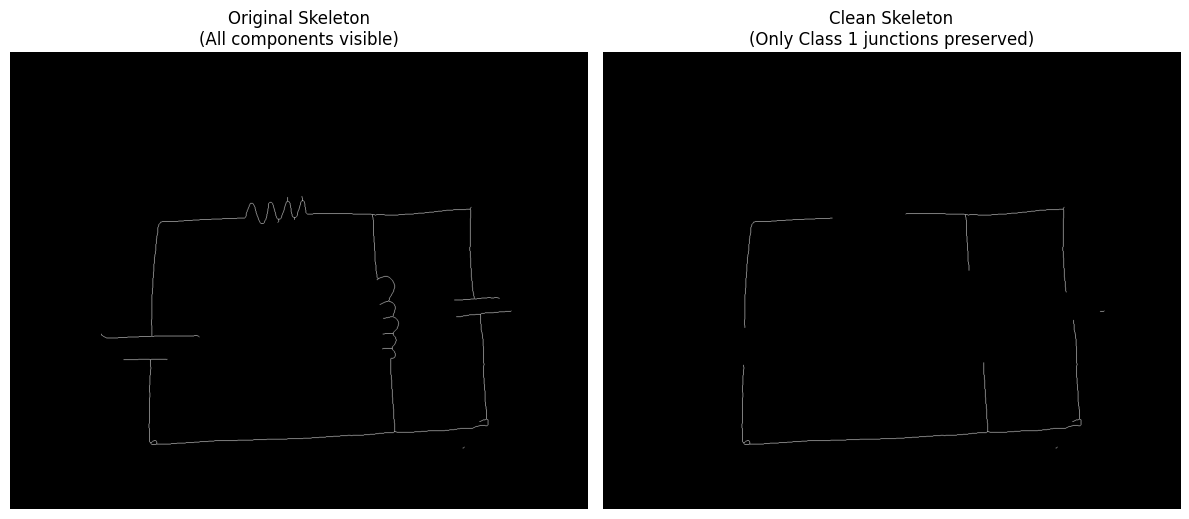

✅ READY FOR PATHFINDING:
   - Clean skeleton created with only Class 1 components
   - 15 endpoints calculated
   - 6 junction points available
   - 9 target intersection points


In [22]:
def remove_components_keep_class1(image, label_path):
    """
    Remove all components except Class 1 (junctions) from the skeleton image.
    This creates a clean skeleton with only junction areas preserved.
    """
    # Create a copy to avoid modifying the original
    cleaned_img = image.copy()
    
    # Get image dimensions
    img_h, img_w = cleaned_img.shape[:2]
    
    # Define eraser color for grayscale (black = 0)
    ERASER_COLOR = 0
    
    try:
        with open(label_path, 'r') as f:
            lines = f.readlines()
            
        print(f"Processing {len(lines)} components from label file...")
        
        removed_count = 0
        kept_count = 0
        
        for line in lines:
            parts = line.strip().split()
            if not parts: 
                continue
            
            class_id = int(parts[0])
            
            # LOGIC: Remove everything EXCEPT Class 1 (junctions)
            if class_id != 1:
                # Parse normalized coordinates (0 to 1)
                x_center, y_center = float(parts[1]), float(parts[2])
                box_w, box_h = float(parts[3]), float(parts[4])
                
                # Convert to pixel coordinates
                x1 = int((x_center - box_w / 2) * img_w)
                y1 = int((y_center - box_h / 2) * img_h)
                x2 = int((x_center + box_w / 2) * img_w)
                y2 = int((y_center + box_h / 2) * img_h)
                
                # Clip coordinates to image bounds
                x1, y1 = max(0, x1), max(0, y1)
                x2, y2 = min(img_w, x2), min(img_h, y2)
                
                # Draw filled black rectangle to erase component
                cv2.rectangle(cleaned_img, (x1, y1), (x2, y2), ERASER_COLOR, thickness=-1)
                
                removed_count += 1
                print(f"  Removed Class {class_id} component at bbox ({x1},{y1}) to ({x2},{y2})")
            else:
                kept_count += 1
                print(f"  Kept Class {class_id} (junction) component")
                
        print(f"\n✅ Component removal complete:")
        print(f"   - Removed: {removed_count} components")
        print(f"   - Kept: {kept_count} Class 1 (junction) components")
        print(f"   - Clean skeleton ready for pathfinding")
        
        return cleaned_img

    except FileNotFoundError:
        print(f"❌ Error: The file {label_path} was not found.")
        return image

# Execute component removal
print("REMOVING ALL COMPONENTS EXCEPT CLASS 1 (JUNCTIONS)")
print("=" * 60)

label_path = '/Users/mac/Downloads/LineDetect/ImageData/imgtotest.txt'

# Start with the skeleton image (convert to proper format)
skeleton_img = skel.astype(np.uint8) * 255  # Convert boolean skeleton to 0-255 grayscale

print(f"Original skeleton image shape: {skeleton_img.shape}")
print(f"Skeleton pixel count: {np.sum(skel)} pixels")

# Run the component removal
clean_skeleton = remove_components_keep_class1(skeleton_img, label_path)

print(f"\nCleaned skeleton shape: {clean_skeleton.shape}")
print(f"Remaining skeleton pixels: {np.sum(clean_skeleton > 0)} pixels")

# Display the result
plt.figure(figsize=(12, 10))

# Create side-by-side comparison
plt.subplot(1, 2, 1)
plt.imshow(skeleton_img, cmap='gray', vmin=0, vmax=255)
plt.title("Original Skeleton\n(All components visible)")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(clean_skeleton, cmap='gray', vmin=0, vmax=255)
plt.title("Clean Skeleton\n(Only Class 1 junctions preserved)")
plt.axis('off')

plt.tight_layout()
plt.show()

print("=" * 60)
print("✅ READY FOR PATHFINDING:")
print(f"   - Clean skeleton created with only Class 1 components")
print(f"   - {len(pathfinding_endpoints)} endpoints calculated")
print(f"   - {len(class_1_coordinates)} junction points available")
print(f"   - {len(all_other_intersection_points)} target intersection points")
print("=" * 60)

# Step 6: BFS Pathfinding Between Endpoints

Now we'll implement BFS (Breadth-First Search) to find paths between all pairs of endpoints on the clean skeleton. If a path exists between two endpoints, we'll store that pair for further processing.

In [23]:
from collections import deque
import itertools
import time

def bfs_pathfinding(start, goal, skeleton_binary):
    """
    BFS pathfinding on skeleton from start to goal.
    
    Parameters:
    - start: (x, y) starting coordinate
    - goal: (x, y) goal coordinate  
    - skeleton_binary: 2D numpy array where 1 = passable skeleton pixel, 0 = blocked
    
    Returns:
    - path: list of (x, y) coordinates from start to goal, or None if no path
    - distance: number of steps in path, or -1 if no path
    """
    if start == goal:
        return [start], 0
    
    height, width = skeleton_binary.shape
    sx, sy = start
    gx, gy = goal
    
    # Check if start and goal are valid skeleton pixels
    if (sx < 0 or sx >= width or sy < 0 or sy >= height or 
        skeleton_binary[sy, sx] == 0):
        return None, -1
    
    if (gx < 0 or gx >= width or gy < 0 or gy >= height or 
        skeleton_binary[gy, gx] == 0):
        return None, -1
    
    # BFS setup
    queue = deque([(sx, sy, [(sx, sy)])])  # (x, y, path)
    visited = set()
    visited.add((sx, sy))
    
    # 8-connectivity directions (including diagonals)
    directions = [(-1,-1), (-1,0), (-1,1), (0,-1), (0,1), (1,-1), (1,0), (1,1)]
    
    while queue:
        x, y, path = queue.popleft()
        
        # Check all 8 neighbors
        for dx, dy in directions:
            nx, ny = x + dx, y + dy
            
            # Check bounds and if it's a skeleton pixel
            if (0 <= nx < width and 0 <= ny < height and 
                skeleton_binary[ny, nx] == 1 and (nx, ny) not in visited):
                
                new_path = path + [(nx, ny)]
                
                # Check if we reached the goal
                if (nx, ny) == (gx, gy):
                    return new_path, len(new_path) - 1
                
                queue.append((nx, ny, new_path))
                visited.add((nx, ny))
    
    return None, -1  # No path found


# Prepare skeleton for BFS
print("Preparing skeleton for BFS pathfinding...")
print("=" * 60)

# Convert clean_skeleton to binary (1 = passable, 0 = blocked)
skeleton_binary = (clean_skeleton > 0).astype(np.uint8)

print(f"Clean skeleton shape: {clean_skeleton.shape}")
print(f"Passable skeleton pixels: {np.sum(skeleton_binary)} pixels")
print(f"Blocked pixels: {np.sum(skeleton_binary == 0)} pixels")

# Collect all unique endpoints for pathfinding
all_endpoints = []

# Add Class 1 coordinates (junctions)
for point in class_1_coordinates:
    all_endpoints.append(point)

# Add all other intersection points
for point in all_other_intersection_points:
    all_endpoints.append(point)

# Remove duplicates while preserving order
unique_endpoints = []
seen = set()
for point in all_endpoints:
    if point not in seen:
        unique_endpoints.append(point)
        seen.add(point)

print(f"\nTotal unique endpoints for pathfinding: {len(unique_endpoints)}")
print(f"Endpoints: {unique_endpoints}")

# Verify all endpoints are on skeleton, find nearest if not
valid_endpoints = []
corrected_endpoints = []

print(f"\nEndpoint validation and correction:")
print("-" * 40)

for i, (x, y) in enumerate(unique_endpoints):
    if (0 <= x < skeleton_binary.shape[1] and 0 <= y < skeleton_binary.shape[0] and 
        skeleton_binary[y, x] == 1):
        # Endpoint is already on skeleton
        valid_endpoints.append((x, y))
        print(f"✅ Endpoint {i+1}: {(x, y)} - Already on skeleton")
    else:
        # Endpoint not on skeleton - find nearest skeleton pixel
        print(f"⚠️  Endpoint {i+1}: {(x, y)} - Not on skeleton, finding nearest...")
        
        # Find nearest skeleton pixel using the existing function
        nearest_point, distance = find_nearest_skeleton_pixel((x, y), skeleton_binary)
        
        if nearest_point is not None:
            valid_endpoints.append(nearest_point)
            corrected_endpoints.append({
                'original': (x, y),
                'corrected': nearest_point,
                'distance': distance
            })
            print(f"✅ Corrected to: {nearest_point} (distance: {distance:.2f} pixels)")
        else:
            print(f"❌ No skeleton pixel found for {(x, y)} - skeleton may be empty!")

print(f"\n📊 ENDPOINT CORRECTION SUMMARY:")
print(f"   Original endpoints: {len(unique_endpoints)}")
print(f"   Already on skeleton: {len(unique_endpoints) - len(corrected_endpoints)}")
print(f"   Corrected to skeleton: {len(corrected_endpoints)}")
print(f"   Final valid endpoints: {len(valid_endpoints)}")

if corrected_endpoints:
    print(f"\n🔧 CORRECTED ENDPOINTS:")
    for correction in corrected_endpoints:
        orig = correction['original']
        corr = correction['corrected'] 
        dist = correction['distance']
        print(f"   {orig} → {corr} (moved {dist:.1f} pixels)")

print("=" * 60)

Preparing skeleton for BFS pathfinding...
Clean skeleton shape: (926, 1171)
Passable skeleton pixels: 2219 pixels
Blocked pixels: 1082127 pixels

Total unique endpoints for pathfinding: 15
Endpoints: [(np.int64(779), np.int64(767)), (np.int64(932), np.int64(316)), (np.int64(733), np.int64(329)), (np.int64(286), np.int64(791)), (np.int64(305), np.int64(344)), (np.int64(968), np.int64(750)), (np.int64(287), np.int64(560)), (np.int64(284), np.int64(632)), (np.int64(612), np.int64(328)), (np.int64(466), np.int64(336)), (np.int64(741), np.int64(443)), (np.int64(771), np.int64(627)), (np.int64(938), np.int64(488)), (np.int64(1006), np.int64(525)), (np.int64(953), np.int64(542))]

Endpoint validation and correction:
----------------------------------------
✅ Endpoint 1: (np.int64(779), np.int64(767)) - Already on skeleton
✅ Endpoint 2: (np.int64(932), np.int64(316)) - Already on skeleton
✅ Endpoint 3: (np.int64(733), np.int64(329)) - Already on skeleton
✅ Endpoint 4: (np.int64(286), np.int64(

In [24]:
# Find all connected endpoint pairs using BFS
print("RUNNING BFS PATHFINDING BETWEEN ALL ENDPOINT PAIRS")
print("=" * 60)

connected_pairs = []  # List to store pairs with valid paths: [(start, end), ...]
pathfinding_results = []  # Detailed results for each pair tested

# Get all unique combinations of endpoints (no duplicates, no self-pairs)
endpoint_pairs = list(itertools.combinations(valid_endpoints, 2))
total_pairs = len(endpoint_pairs)

print(f"Testing {total_pairs} unique endpoint pairs for connectivity...")
print("(This may take a moment depending on skeleton complexity)")

start_time = time.time()

# Track endpoints that already found connections
connected_endpoints = set()

# Test each pair for connectivity
for i, (start, end) in enumerate(endpoint_pairs):
    if i % 10 == 0 or i == total_pairs - 1:  # Progress indicator
        print(f"  Progress: {i+1}/{total_pairs} pairs tested...")
    
    # Skip if both endpoints already found connections
    if start in connected_endpoints and end in connected_endpoints:
        print(f"    Skipping {start} ↔ {end} - both endpoints already connected")
        # Store as skipped result
        result = {
            'pair_index': i,
            'start': start,
            'end': end,
            'path_found': False,
            'path_length': -1,
            'path': None,
            'skipped': True
        }
        pathfinding_results.append(result)
        continue
    
    # Run BFS pathfinding
    path, distance = bfs_pathfinding(start, end, skeleton_binary)
    
    # Store results
    result = {
        'pair_index': i,
        'start': start,
        'end': end,
        'path_found': path is not None,
        'path_length': distance,
        'path': path,
        'skipped': False
    }
    pathfinding_results.append(result)
    
    # If path found, add to connected pairs and mark endpoints as connected
    if path is not None:
        connected_pairs.append((start, end))
        connected_endpoints.add(start)
        connected_endpoints.add(end)
        print(f"    ✅ Connection found: {start} ↔ {end} (distance: {distance} pixels)")
        print(f"    📍 Endpoints {start} and {end} marked as connected")

end_time = time.time()

# Calculate statistics including skipped pairs
total_tested = len([r for r in pathfinding_results if not r.get('skipped', False)])
total_skipped = len([r for r in pathfinding_results if r.get('skipped', False)])

print(f"\n✅ BFS PATHFINDING COMPLETE!")
print(f"   Time taken: {end_time - start_time:.2f} seconds")
print(f"   Total pairs considered: {total_pairs}")
print(f"   Pairs actually tested: {total_tested}")
print(f"   Pairs skipped (endpoints already connected): {total_skipped}")
print(f"   Connected pairs found: {len(connected_pairs)}")
print(f"   Disconnected pairs: {total_tested - len(connected_pairs)}")
print(f"   Endpoints with connections: {len(connected_endpoints)}")

# Calculate efficiency
efficiency = (total_skipped / total_pairs * 100) if total_pairs > 0 else 0
print(f"   Efficiency gain: {efficiency:.1f}% pairs avoided")

# Display connected pairs
if connected_pairs:
    print(f"\n🔗 CONNECTED ENDPOINT PAIRS:")
    print("-" * 50)
    for i, (start, end) in enumerate(connected_pairs):
        # Find the path details for this pair
        result = next(r for r in pathfinding_results if r['start'] == start and r['end'] == end)
        print(f"  {i+1:2d}. {start} ↔ {end} (distance: {result['path_length']} pixels)")
    
    print(f"\n📋 STORED PAIRS FORMAT: {connected_pairs}")
else:
    print("\n❌ No connected pairs found!")
    print("   This could mean:")
    print("   - Endpoints are on separate skeleton components")
    print("   - Skeleton is too fragmented")
    print("   - Component removal created disconnected regions")

# Summary statistics
connectivity_rate = len(connected_pairs) / total_pairs * 100 if total_pairs > 0 else 0
avg_path_length = np.mean([r['path_length'] for r in pathfinding_results if r['path_found']]) if connected_pairs else 0

print(f"\n📊 PATHFINDING STATISTICS:")
print("-" * 40)
print(f"Connectivity rate: {connectivity_rate:.1f}%")
if avg_path_length > 0:
    print(f"Average path length: {avg_path_length:.1f} pixels")

# Show distribution of path lengths
if connected_pairs:
    path_lengths = [r['path_length'] for r in pathfinding_results if r['path_found']]
    print(f"Path length range: {min(path_lengths)} - {max(path_lengths)} pixels")

print("=" * 60)

RUNNING BFS PATHFINDING BETWEEN ALL ENDPOINT PAIRS
Testing 105 unique endpoint pairs for connectivity...
(This may take a moment depending on skeleton complexity)
  Progress: 1/105 pairs tested...
    ✅ Connection found: (np.int64(779), np.int64(767)) ↔ (np.int64(286), np.int64(791)) (distance: 497 pixels)
    📍 Endpoints (np.int64(779), np.int64(767)) and (np.int64(286), np.int64(791)) marked as connected
    ✅ Connection found: (np.int64(779), np.int64(767)) ↔ (np.int64(968), np.int64(750)) (distance: 195 pixels)
    📍 Endpoints (np.int64(779), np.int64(767)) and (np.int64(968), np.int64(750)) marked as connected
    ✅ Connection found: (np.int64(779), np.int64(767)) ↔ (np.int64(284), np.int64(634)) (distance: 654 pixels)
    📍 Endpoints (np.int64(779), np.int64(767)) and (np.int64(284), np.int64(634)) marked as connected
  Progress: 11/105 pairs tested...
    ✅ Connection found: (np.int64(779), np.int64(767)) ↔ (np.int64(771), np.int64(629)) (distance: 138 pixels)
    📍 Endpoints (n

VISUALIZING CONNECTED PATHS


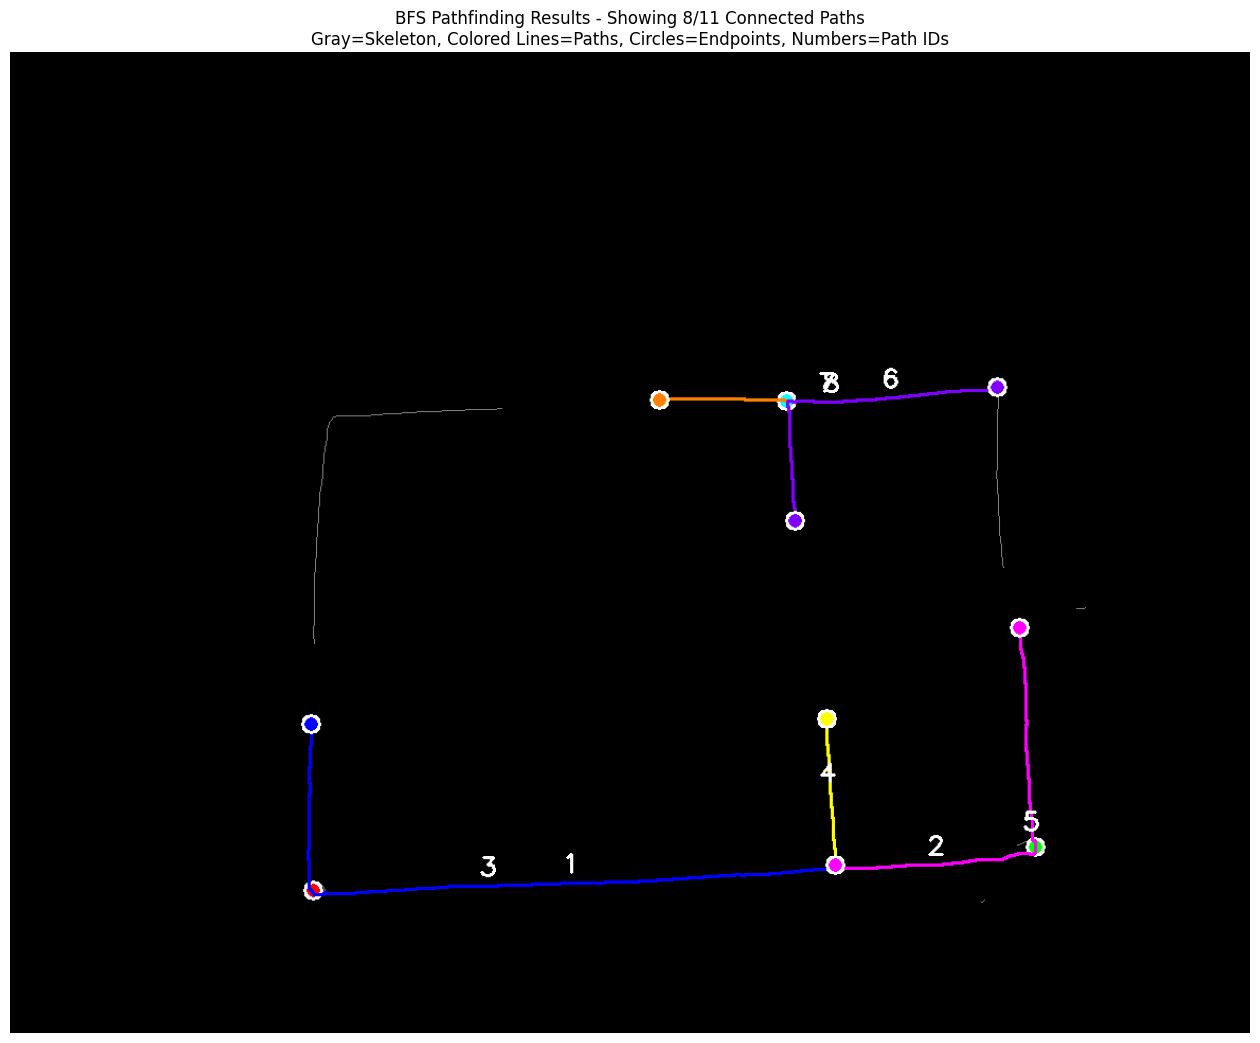


PATH VISUALIZATION LEGEND (First 8 paths):
--------------------------------------------------
Path 1 (Red): (np.int64(779), np.int64(767)) → (np.int64(286), np.int64(791)) (497 pixels)
Path 2 (Green): (np.int64(779), np.int64(767)) → (np.int64(968), np.int64(750)) (195 pixels)
Path 3 (Blue): (np.int64(779), np.int64(767)) → (np.int64(284), np.int64(634)) (654 pixels)
Path 4 (Yellow): (np.int64(779), np.int64(767)) → (np.int64(771), np.int64(629)) (138 pixels)
Path 5 (Magenta): (np.int64(779), np.int64(767)) → (np.int64(953), np.int64(543)) (403 pixels)
Path 6 (Cyan): (np.int64(932), np.int64(316)) → (np.int64(733), np.int64(329)) (200 pixels)
Path 7 (Orange): (np.int64(932), np.int64(316)) → (np.int64(613), np.int64(328)) (320 pixels)
Path 8 (Purple): (np.int64(932), np.int64(316)) → (np.int64(741), np.int64(442)) (311 pixels)

... and 3 more connected pairs

✅ FINAL RESULT - CONNECTED ENDPOINT PAIRS:
📋 Stored in 'connected_pairs': [((np.int64(779), np.int64(767)), (np.int64(286), np.

In [25]:
# Visualize connected paths on the skeleton
print("VISUALIZING CONNECTED PATHS")
print("=" * 40)

if connected_pairs:
    plt.figure(figsize=(16, 16))
    
    # Create visualization image
    vis_img = np.zeros((skeleton_binary.shape[0], skeleton_binary.shape[1], 3), dtype=np.uint8)
    
    # Draw skeleton in gray
    vis_img[skeleton_binary == 1] = [128, 128, 128]  # Gray skeleton
    
    # Colors for different paths
    path_colors = [
        (255, 0, 0),    # Red
        (0, 255, 0),    # Green  
        (0, 0, 255),    # Blue
        (255, 255, 0),  # Yellow
        (255, 0, 255),  # Magenta
        (0, 255, 255),  # Cyan
        (255, 128, 0),  # Orange
        (128, 0, 255),  # Purple
    ]
    
    # Draw first few connected paths with different colors
    max_paths_to_show = min(len(connected_pairs), 8)  # Limit for clarity
    
    for i, (start, end) in enumerate(connected_pairs[:max_paths_to_show]):
        color = path_colors[i % len(path_colors)]
        
        # Get the path for this pair
        result = next(r for r in pathfinding_results if r['start'] == start and r['end'] == end)
        path = result['path']
        
        if path:
            # Draw path as line segments
            for j in range(len(path) - 1):
                pt1 = path[j]
                pt2 = path[j + 1]
                cv2.line(vis_img, pt1, pt2, color, 2)
            
            # Draw start and end points as circles
            cv2.circle(vis_img, start, 8, color, -1)  # Filled circle
            cv2.circle(vis_img, start, 8, (255, 255, 255), 2)  # White border
            cv2.circle(vis_img, end, 8, color, -1)    # Filled circle  
            cv2.circle(vis_img, end, 8, (255, 255, 255), 2)    # White border
            
            # Add path number labels
            mid_point = path[len(path) // 2]
            cv2.putText(vis_img, str(i + 1), (mid_point[0] - 10, mid_point[1] - 10),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)
    
    plt.imshow(vis_img)
    plt.title(f"BFS Pathfinding Results - Showing {max_paths_to_show}/{len(connected_pairs)} Connected Paths\n" +
              f"Gray=Skeleton, Colored Lines=Paths, Circles=Endpoints, Numbers=Path IDs")
    plt.axis('off')
    plt.show()
    
    # Create legend for paths shown
    print(f"\nPATH VISUALIZATION LEGEND (First {max_paths_to_show} paths):")
    print("-" * 50)
    color_names = ["Red", "Green", "Blue", "Yellow", "Magenta", "Cyan", "Orange", "Purple"]
    
    for i in range(max_paths_to_show):
        start, end = connected_pairs[i]
        result = next(r for r in pathfinding_results if r['start'] == start and r['end'] == end)
        color_name = color_names[i % len(color_names)]
        print(f"Path {i+1} ({color_name}): {start} → {end} ({result['path_length']} pixels)")
    
    if len(connected_pairs) > max_paths_to_show:
        print(f"\n... and {len(connected_pairs) - max_paths_to_show} more connected pairs")
        
else:
    print("No connected paths to visualize.")

print("\n" + "=" * 40)
print("✅ FINAL RESULT - CONNECTED ENDPOINT PAIRS:")
print(f"📋 Stored in 'connected_pairs': {connected_pairs}")
print("=" * 40)

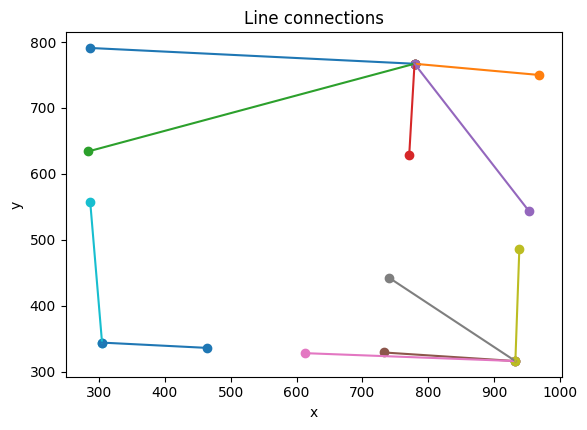

Total pairs plotted: 11


In [26]:
import matplotlib.pyplot as plt

counter = 0

pairs = [
    ((779, 767), (286, 791)),
    ((779, 767), (968, 750)),
    ((779, 767), (284, 634)),
    ((779, 767), (771, 629)),
    ((779, 767), (953, 543)),
    ((932, 316), (733, 329)),
    ((932, 316), (613, 328)),
    ((932, 316), (741, 442)),
    ((932, 316), (938, 486)),
    ((305, 344), (287, 558)),
    ((305, 344), (464, 336)),
]


plt.figure()
for (x1, y1), (x2, y2) in pairs:
    plt.plot([x1, x2], [y1, y2])
    counter = counter + 1
    plt.scatter([x1, x2], [y1, y2])

plt.gca().set_aspect("equal", adjustable="box")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Line connections")
plt.show()
print(f"Total pairs plotted: {counter}")
